# Final Results

We collect here the models we have chosen for each borough thus far. Our goal here is to show the final model training, evaluation, and relevant plots. What is reproduced here can be found in the evaluations notebooks inside the folders for the boroughs and citywide level e.g. [5evaluations.ipynb](./citywide/5evaluations.ipynb) in the citywide folder.

<div style="text-align:center">

|         Level         |                                        Chosen Model                                                    |                  Folder                 |
| :-------------------: | :----------------------------------------------------------------------------------------------------: | :-------------------------------------: |
|        Citywide       |                        [Hybrid Prophet + XGBoost](./citywide/5evaluations.ipynb)                       |         [citywide](./citywide/)         |
|       Manhattan       |                         [NeuralProphet](./manhattan/2neural_solo_prophet.ipynb)                        |        [manhattan](./manhattan/)        |
|        Brooklyn       |                              [NeuralProphet](./brooklyn/3evaluation.ipynb)                             |         [brooklyn](./brooklyn/)         |
|      Staten Island    |                         [Prophet](./staten_island/1modeling_experiments.ipynb)                         | [staten_island](./staten_island/)       |
|         Queens        | [Prophet](./bronx_and_queens/1modeling_experiments.ipynb) | [bronx_and_queens](./bronx_and_queens/)    |                                         |
|         Bronx         |                        [Prophet](./bronx_and_queens/1modeling_experiments.ipynb)                       | [bronx_and_queens](./bronx_and_queens/) |

</div>

## Load Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from prophet import Prophet
from pandas.tseries.holiday import USFederalHolidayCalendar
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
import logging
logging.getLogger("cmdstanpy").disabled = True
import xgboost as xgb
import optuna
from neuralprophet import NeuralProphet
import logging


Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


## Citywide

In [ ]:
# This cell defines functions to add features for XGBoost 

def create_features(df):
    df = df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

def add_cyclic(df):
    target_map = df['y'].to_dict()
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek']/7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek']/7)
    df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
    df['month_cos'] = np.cos(2 * np.pi * df['month']/12)
    return df

def add_lags(df):
    # lags
    target_map = df['y'].to_dict()
    df['lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df['lag16'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    return df

def add_seasonal_lags(df):
    # lags of various lengths for different levels of seasonality
    target_map = df['y'].to_dict()
    df['lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)

    df['lag362'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag363'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag364'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag366'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag367'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    
    df['lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)
    df['lag1095'] = (df.index - pd.Timedelta('1095 days')).map(target_map)
    df['lag1460'] = (df.index - pd.Timedelta('1460 days')).map(target_map)
    df['lag1825'] = (df.index - pd.Timedelta('1825 days')).map(target_map)
    return df

def add_moving_averages(df):
    df = df.copy()
    df = df.sort_index()
    # Must shift by 14 days because we do not want to let there be temporal leakage in our evaluations
    df['ma7'] = df['y'].shift(14).rolling(window=7).mean()
    df['ma30'] = df['y'].shift(14).rolling(window=30).mean()
    df['ma60'] = df['y'].shift(14).rolling(window=60).mean()
    df['ma90'] = df['y'].shift(14).rolling(window=90).mean()
    df['ma120'] = df['y'].shift(14).rolling(window=120).mean()
    df['ma150'] = df['y'].shift(14).rolling(window=150).mean()
    df['ma180'] = df['y'].shift(14).rolling(window=180).mean()
    df['ma365'] = df['y'].shift(14).rolling(window=365).mean()
    
    return df


## Add weather data.

import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2026-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()


wd = pd.DataFrame(data["daily"])
wd["date"] = pd.to_datetime(wd["time"])
wd = wd.set_index("date")


def add_weather_data(df, wd):
    df = df.copy()
    wd = wd.copy()
    df.index = pd.to_datetime(df.index)
    wd.index = pd.to_datetime(wd.index)
    if "time" in wd.columns:
        wd = wd.drop(columns=["time"])
    overlap = wd.columns.intersection(df.columns)
    wd = wd.drop(columns=overlap)
    df = df.join(wd, how="left")
    return df

def add_more_weather_feature(df):
    target_map = df['apparent_temperature_min'].to_dict()
    df['apparent_temperature_min_lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['apparent_temperature_min_lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df['apparent_temperature_min_lag16'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    df['apparent_temperature_min_lag17'] = (df.index - pd.Timedelta('17 days')).map(target_map)
    df['apparent_temperature_min_lag18'] = (df.index - pd.Timedelta('18 days')).map(target_map)
    df['apparent_temperature_min_lag19'] = (df.index - pd.Timedelta('19 days')).map(target_map)
    df['apparent_temperature_min_lag20'] = (df.index - pd.Timedelta('20 days')).map(target_map)
    df['apparent_temperature_min_lag21'] = (df.index - pd.Timedelta('21 days')).map(target_map)

    df['apparent_temperature_min_lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['apparent_temperature_min_lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['apparent_temperature_min_lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['apparent_temperature_min_lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['apparent_temperature_min_lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['apparent_temperature_min_lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)
    df['apparent_temperature_min_lag210'] = (df.index - pd.Timedelta('210 days')).map(target_map)
    df['apparent_temperature_min_lag240'] = (df.index - pd.Timedelta('240 days')).map(target_map)
    df['apparent_temperature_min_lag270'] = (df.index - pd.Timedelta('270 days')).map(target_map)
    df['apparent_temperature_min_lag300'] = (df.index - pd.Timedelta('300 days')).map(target_map)
    df['apparent_temperature_min_lag330'] = (df.index - pd.Timedelta('330 days')).map(target_map)
    df['apparent_temperature_min_lag360'] = (df.index - pd.Timedelta('360 days')).map(target_map)
    df['apparent_temperature_min_lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['apparent_temperature_min_lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)

    target_map = df['temperature_2m_max'].to_dict()
    df['temperature_2m_max_lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['temperature_2m_max_lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['temperature_2m_max_lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)

    return df


date_range = pd.date_range(start="2020-01-01", end="2026-02-28")
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())
federal_holidays = pd.DataFrame({'holiday': 'federal_us', 'ds': pd.to_datetime(holidays), 'lower_window': 0, 'upper_window': 1})

holidays = federal_holidays


def add_federal_holidays(df, custom_holidays=None):
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    
    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=df.index.min(), end=df.index.max())

    if custom_holidays:
        for d in custom_holidays:
            if len(d) == 5:  # MM-DD format handling
                years = df.index.year.unique()
                for y in years:
                    holidays = holidays.append(pd.to_datetime([f"{y}-{d}"]))
            else:  # YYYY-MM-DD format handling
                holidays = holidays.append(pd.to_datetime([d]))
                
    holidays = holidays.drop_duplicates().sort_values()
    
    df["is_federal_holiday"] = df.index.isin(holidays).astype(int)
    
    return df

def add_law_flag(df, law_name: str, start_date: str):
    # Adds a binary column to indicate when a new law is active.
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    start_dt = pd.to_datetime(start_date)
    # Create binary column: 1 if date >= start_date, else 0
    df[law_name] = (df.index >= start_dt).astype(int)
    
    return df

def add_new_lags(df, x):
    # lags
    target_map = df[x].to_dict()
    df[f'{x}lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df[f'{x}lag16'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    df[f'{x}lag17'] = (df.index - pd.Timedelta('17 days')).map(target_map)
    df[f'{x}lag18'] = (df.index - pd.Timedelta('18 days')).map(target_map)
    df[f'{x}lag19'] = (df.index - pd.Timedelta('19 days')).map(target_map)
    df[f'{x}lag20'] = (df.index - pd.Timedelta('20 days')).map(target_map)
    df[f'{x}lag21'] = (df.index - pd.Timedelta('21 days')).map(target_map)

    df[f'{x}lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df[f'{x}lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df[f'{x}lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)
    return df

In [ ]:
# These are all of the features considered

ALL_FEATURES = {'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear', 'dayofweek_sin', 'dayofweek_cos',
       'month_sin', 'month_cos', 'lag15', 'lag16', 'lag30', 'lag60', 'lag90',
       'lag120', 'lag150', 'lag180', 'lag362', 'lag363', 'lag364', 'lag365',
       'lag366', 'lag367', 'lag730', 'lag1095', 'lag1460', 'lag1825', 'ma7',
       'ma30', 'ma60', 'ma90', 'ma120', 'ma150', 'ma180', 'ma365',
       'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
       'apparent_temperature_max', 'apparent_temperature_min',
       'apparent_temperature_mean', 'precipitation_sum', 'snowfall_sum',
       'apparent_temperature_min_lag14', 'apparent_temperature_min_lag15',
       'apparent_temperature_min_lag16', 'apparent_temperature_min_lag17',
       'apparent_temperature_min_lag18', 'apparent_temperature_min_lag19',
       'apparent_temperature_min_lag20', 'apparent_temperature_min_lag21',
       'apparent_temperature_min_lag30', 'apparent_temperature_min_lag60',
       'apparent_temperature_min_lag90', 'apparent_temperature_min_lag120',
       'apparent_temperature_min_lag150', 'apparent_temperature_min_lag180',
       'apparent_temperature_min_lag210', 'apparent_temperature_min_lag240',
       'apparent_temperature_min_lag270', 'apparent_temperature_min_lag300',
       'apparent_temperature_min_lag330', 'apparent_temperature_min_lag360',
       'apparent_temperature_min_lag365', 'apparent_temperature_min_lag730',
       'temperature_2m_max_lag14', 'temperature_2m_max_lag30',
       'temperature_2m_max_lag60', 'is_federal_holiday', 'Trash_Law',
       'New_Trash_Law', 'Rat_Mitigation_Zone', 'Rat_Czar_Appointed',
       'residuals', 'residualslag15', 'residualslag16', 'residualslag17',
       'residualslag18', 'residualslag19', 'residualslag20', 'residualslag21',
       'residualslag30', 'residualslag365', 'residualslag730', 'trend',
       'yhat_lower', 'yhat_upper'}

In [ ]:
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)

In [4]:
# Load in the saved parameters and features

study = optuna.create_study(
    direction="minimize",
    study_name="hybrid_model_feature_parameter_search",
    storage=f"sqlite:///citywide/xgbprophet_model26.db",
    load_if_exists=True
)

best_params = study.best_params
print(best_params)

print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)


best_features = [f for f in ALL_FEATURES if study.best_params.get(f, False)]

best_hyperparams = {k: v for k, v in study.best_params.items() if k not in ALL_FEATURES}
print("Selected Features:")
print(best_features)

print("\nBest Hyperparameters:")
print(best_hyperparams)

prophet_keys = ["changepoint_prior_scale", "seasonality_prior_scale", "holidays_prior_scale"]

# extract subset
best_prophet_params = {k: best_hyperparams[k] for k in prophet_keys if k in best_hyperparams}


xgb_keys = ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'gamma', 'min_child_weight', 'reg_lambda', 'reg_alpha'] 

# extract subset
best_xgb_params = {k: best_hyperparams[k] for k in xgb_keys if k in best_hyperparams}


[I 2026-03-19 01:07:43,783] Using an existing study with name 'hybrid_model_feature_parameter_search' instead of creating a new one.


{'changepoint_prior_scale': 0.1476254975588991, 'seasonality_prior_scale': 0.3547339983371146, 'holidays_prior_scale': 2.274344908057226, 'n_estimators': 1916, 'max_depth': 4, 'learning_rate': 0.00198485296210223, 'subsample': 0.7100035979775448, 'colsample_bytree': 0.5770065237411632, 'gamma': 1.7585730706879485, 'min_child_weight': 8, 'reg_lambda': 1.1303130099058791, 'reg_alpha': 7.04862540806253, 'lag363': True, 'apparent_temperature_min_lag14': False, 'dayofweek_cos': False, 'is_federal_holiday': False, 'dayofyear': False, 'apparent_temperature_min_lag120': False, 'Rat_Czar_Appointed': False, 'ma365': False, 'lag30': False, 'lag730': False, 'apparent_temperature_min_lag16': True, 'residuals': False, 'residualslag15': True, 'Trash_Law': False, 'apparent_temperature_min_lag360': True, 'lag16': True, 'apparent_temperature_min_lag240': True, 'weekofyear': True, 'residualslag365': True, 'apparent_temperature_min_lag180': True, 'lag365': True, 'ma90': True, 'dayofweek': False, 'lag366':

In [ ]:
# Load in data
rs = pd.read_csv('../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
save = rs['ds'].copy().values
rs = rs.set_index('ds')
rs.index = pd.to_datetime(rs.index)
rs['ds']=save
rs = create_features(rs)
rs = add_cyclic(rs)
rs = add_lags(rs)
rs = add_seasonal_lags(rs)
rs = add_moving_averages(rs)
rs = add_weather_data(rs,wd)
rs = add_more_weather_feature(rs)
rs = add_federal_holidays(rs, custom_holidays = ['12-31'])
rs = add_law_flag(rs, law_name='Trash_Law', start_date = '2024-03-01')
rs = add_law_flag(rs, law_name = 'New_Trash_Law', start_date = '2024-11-01')
rs = add_law_flag(rs, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
rs = add_law_flag(rs, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')
FEATURES = best_features

In [6]:
def forward_fill_rows(df, seed_row, include_columns=None):
    df_ffilled = df.copy()
    
    if include_columns is None:
        # if no columns specified, forward-fill all
        include_columns = df_ffilled.columns.tolist()
    
    for i in range(len(df_ffilled)):
        if i == 0:
            # first row takes seed_row for included columns
            for col in include_columns:
                df_ffilled.at[df_ffilled.index[i], col] = seed_row[col]
        else:
            # subsequent rows take previous row for included columns
            for col in include_columns:
                df_ffilled.at[df_ffilled.index[i], col] = df_ffilled.at[df_ffilled.index[i-1], col]
                
    return df_ffilled

In [7]:
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):

    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()


    # Forward-fill test using last row of train
    test = forward_fill_rows(test, 
                            seed_row=train.iloc[-1], 
                            include_columns=['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
                                            'apparent_temperature_max', 'apparent_temperature_min',
                                            'apparent_temperature_mean', 'precipitation_sum', 'snowfall_sum',])

    model = Prophet(**best_prophet_params, holidays=holidays)
    model.add_country_holidays(country_name='US')
    model.fit(train)

    train_future = model.make_future_dataframe(periods=0, freq='D')
    train_forecast = model.predict(train_future)

    train_residuals = train['y'].values - train_forecast['yhat'].values

    residuals_df = pd.DataFrame({'ds': train['ds'],'y': train_residuals})

    train['residuals'] = train_residuals

    add_new_lags(train, 'residuals')

    train['trend'] = train_forecast['trend'].values
    train['yhat_lower'] = train_forecast['yhat_lower'].values
    train['yhat_upper'] = train_forecast['yhat_upper'].values

    X_train_residuals = train[FEATURES]
    y_train_residuals = residuals_df['y']

    # Train XGBoost
    xgb_model = xgb.XGBRegressor(**best_xgb_params)
    xgb_model.fit(X_train_residuals, y_train_residuals)

    # Prepare Test Data
    test['residuals'] = np.nan # need to add this otherwise it won't run

    dummy = pd.concat([train, test], axis=0)

    add_new_lags(dummy, 'residuals') # need to add the lags that test can actually see

    test = dummy.iloc[test_index].copy() # cut out the test set again

    # Prophet Forecast
    future = model.make_future_dataframe(periods=len(test), freq='D')
    prophet_forecast = model.predict(future)

    # add outputs of Prophet for use in the XGBoost model
    test.loc[:, 'trend'] = prophet_forecast[-len(test):]['trend'].values
    test.loc[:, 'yhat_lower'] = prophet_forecast[-len(test):]['yhat_lower'].values
    test.loc[:, 'yhat_upper'] = prophet_forecast[-len(test):]['yhat_upper'].values

    X_test = test[FEATURES]

    xgb_residual_preds = xgb_model.predict(X_test)

    y_pred = np.round(prophet_forecast['yhat'][-len(test):].values + xgb_residual_preds)
    y_true = test['y'].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    results.append(rmse)    
    # Store the results for this fold

# Convert the results into a DataFrame
prophet_xgb_results_df = pd.DataFrame(results, columns=["RMSE"])

mean_rmse = prophet_xgb_results_df['RMSE'].mean()
prophet_xgb_results_df.loc['mean'] = [mean_rmse]

In [8]:
citywide_results = prophet_xgb_results_df.copy()
citywide_results

,RMSE
0,12.449900
1,9.015859
2,8.066686
3,10.306032
4,11.631239
5,14.427157
6,10.829853
7,11.113055
8,10.643576
9,8.569047


## Manhattan

In [ ]:
# set up the time series split
rs = pd.read_csv('../scr/data/cleaned_rat_sightings_data/all_daily_borough_rs.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 

# Start by cutting off data before 2020-01-01 and after 2025-02-28.
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2020-01-01']

## Restrict to MANHATTAN

rs = rs[rs['borough']=='MANHATTAN']

## Drop the column with borough

rs = rs.drop(columns=['borough'])


In [10]:
rs['created_date'] = pd.to_datetime(rs['created_date'])
start = rs['created_date'].min()
end = rs['created_date'].max()
rs = (rs.set_index('created_date').reindex(pd.date_range(start, end, freq='D'), fill_value=0).rename_axis('created_date').reset_index())
rs

,created_date,count
0,2020-01-01,4
1,2020-01-02,7
2,2020-01-03,16
3,2020-01-04,10
4,2020-01-05,5
...,...,...
2246,2026-02-24,7
2247,2026-02-25,8
2248,2026-02-26,9
2249,2026-02-27,17


In [11]:
# Create a date range covering 2020 to end
date_range = pd.date_range(start="2020-01-01", end="2026-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

# Build the DataFrame in the same structure as your original
federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1,
})

holidays = federal_holidays

In [12]:
# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    y_pred = np.round(y_pred)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Calculate MAPE
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

# Convert results to a datafrane
prophet_results_df = pd.DataFrame(results)
prophet_results_df.loc['mean'] = ['mean',  prophet_results_df['rmse'].mean(), prophet_results_df['mape'].mean()]
manhattan_results = prophet_results_df.copy()
manhattan_results

,fold,rmse,mape
0,0,4.750940,3.597222e-01
1,1,7.372730,3.214702e-01
2,2,3.770184,2.534078e-01
3,3,3.946065,2.838269e-01
4,4,4.472136,1.851062e-01
5,5,6.256425,4.008408e-01
6,6,5.028490,2.345638e-01
7,7,6.369571,1.960804e-01
8,8,6.017831,2.792741e-01
9,9,5.126960,3.286943e-01


## Brooklyn

In [13]:
np.NaN = np.nan


# the following packages are meant to turn off a bunch of the warnings and ERRORs that pop up while running NeuralProphet.
# the errors that do show up are not all that important and a lot is due to outdated packages.
import warnings
import logging

warnings.filterwarnings("ignore")

logging.getLogger("neuralprophet").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("NP").setLevel(logging.ERROR)

In [14]:
# Load the existing study
study = optuna.load_study(
    study_name="model_neural",
    storage="sqlite:///brooklyn/model_neural.db"
)

# Get the best parameters
best_params = study.best_params
best_value = study.best_value  # Optional: best objective value

print("Best parameters:", best_params)
print("Best objective value:", best_value)

Best parameters: {'lag_temp_max': 40, 'lag_temp_min': 12, 'lag_snowfall': 2, 'n_lags': 28, 'epochs': 249, 'learning_rate': 0.37721078987363893, 'batch_size': 1320, 'ar_reg': 2.538762924452284}
Best objective value: 5.2251618137843145


In [15]:
rs = pd.read_csv('../scr/data/cleaned_rat_sightings_data/all_daily_borough_rs.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 

# Start by cutting off data before 2020-01-01 and after 2026-02-28.
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2020-01-01']

## Restrict to BROOKLYN

rs = rs[rs['borough']=='BROOKLYN']

## Drop the column with borough

rs = rs.drop(columns=['borough'])

## rename columns for prophet

rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)


## Add weather data.
import requests


lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2026-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()


if 'error' in data:
    nd = pd.read_csv("../../scr/data/weather_data/wd_2020_to_march_2026.csv")
    nd = nd.set_index('time')
    wd = nd
    wd["date"] = pd.to_datetime(wd["time"])
    
else:
    wd = pd.DataFrame(data["daily"])
    wd["date"] = pd.to_datetime(wd["time"])
    wd = wd.set_index("date")

In [16]:
regressed_features = ['apparent_temperature_max', 'apparent_temperature_min','snowfall_sum']


wd = wd.reset_index(drop=True).rename(columns={"time": "ds"})
wd["ds"] = pd.to_datetime(wd["ds"])
rs["ds"] = pd.to_datetime(rs["ds"])

rs = rs.merge(
    wd[['ds'] + regressed_features],
    on="ds",
    how="left"
)

lags_for_regressed_features = dict()
lags_for_regressed_features['apparent_temperature_max'] = best_params['lag_temp_max']
lags_for_regressed_features['apparent_temperature_min'] = best_params['lag_temp_min']
lags_for_regressed_features['snowfall_sum'] = best_params['lag_snowfall']


results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):

    train = rs.iloc[train_index].copy()
    train = train.dropna(subset=["y"])

    test = rs.iloc[test_index].copy()


    model = NeuralProphet(yearly_seasonality=True, 
                          weekly_seasonality=True, 
                          learning_rate = best_params['learning_rate'],
                          epochs = best_params['epochs'],
                          n_lags= best_params['n_lags'],
                          ar_reg=best_params['ar_reg'],
                          accelerator="auto",   # uses GPU if available
                          batch_size= best_params['batch_size']
                          )
    model = model.add_country_holidays(country_name="US")
    for column in regressed_features:
        model.add_lagged_regressor(column, n_lags=lags_for_regressed_features[column])
        
    model.fit(train, freq="D", progress="off")

    # build dataframe containing future regressors
    future = pd.concat([train[['ds','y'] + regressed_features], test[['ds','y']].merge(wd[['ds'] + regressed_features], on="ds", how="left")])
    forecast = model.predict(future)

    y_pred = forecast["yhat1"].iloc[-len(test):].values
    y_pred = np.round(y_pred)
    y_true = test["y"].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)

    results.append({"fold": i, "rmse": rmse, "mape": mape})

neural_prophet_results_df = pd.DataFrame(results)
neural_prophet_results_df.loc["mean"] = ["mean", neural_prophet_results_df["rmse"].mean(), neural_prophet_results_df["mape"].mean()]
brooklyn_results = neural_prophet_results_df.copy()
brooklyn_results

Training: 0it [00:00, ?it/s]

Predicting: 2it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Predicting: 2it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

...

Training: 0it [00:00, ?it/s]

Predicting: 2it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Predicting: 2it [00:00, ?it/s]

,fold,rmse,mape
0,0,6.798109,0.316080
1,1,4.200340,0.157050
2,2,5.787918,0.255569
3,3,6.419835,0.171603
4,4,6.425396,0.234936
5,5,7.745967,0.256069
6,6,6.023762,0.189516
7,7,7.722879,0.354862
8,8,6.123724,0.220317
9,9,6.850443,0.195262


## Staten Island

In [17]:
# Load in the data
rs = pd.read_csv('../scr/data/cleaned_rat_sightings_data/all_daily_borough_rs.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 

# Start by cutting off data before 2020-01-01 and after 2025-02-28.
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs[rs['borough']=='STATEN ISLAND']
rs = rs.drop(columns=['borough'])
rs['created_date'] = pd.to_datetime(rs['created_date'])
start = rs['created_date'].min()
end = rs['created_date'].max()
rs = (rs.set_index('created_date').reindex(pd.date_range(start, end, freq='D'), fill_value=0).rename_axis('created_date').reset_index())

# Create a date range covering 2020 to end
date_range = pd.date_range(start="2020-01-01", end="2026-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

# Build the DataFrame in the same structure as your original
federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1,
})

holidays = federal_holidays

# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    y_pred = np.round(y_pred)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Calculate MAPE
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

# Convert results to a datafrane
prophet_results_df = pd.DataFrame(results)
prophet_results_df.loc['mean'] = ['mean',  prophet_results_df['rmse'].mean(), prophet_results_df['mape'].mean()]
staten_island_results = prophet_results_df.copy()

## Bronx

In [18]:
# Load in Bronx data
rs = pd.read_csv('../scr/data/cleaned_rat_sightings_data/all_daily_borough_rs.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs[rs['borough']=='BRONX']
rs = rs.drop(columns=['borough'])
rs['created_date'] = pd.to_datetime(rs['created_date'])
start = rs['created_date'].min()
end = rs['created_date'].max()
rs = (rs.set_index('created_date').reindex(pd.date_range(start, end, freq='D'), fill_value=0).rename_axis('created_date').reset_index())


# Holidays
date_range = pd.date_range(start="2020-01-01", end="2026-02-28")
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())
federal_holidays = pd.DataFrame({'holiday': 'federal_us','ds': pd.to_datetime(holidays),'lower_window': 0,'upper_window': 1,})
holidays = federal_holidays

# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    y_pred = np.round(y_pred)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Calculate MAPE
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

# Convert results to a datafrane
prophet_results_df = pd.DataFrame(results)
prophet_results_df.loc['mean'] = ['mean',  prophet_results_df['rmse'].mean(), prophet_results_df['mape'].mean()]
bronx_results = prophet_results_df.copy()

## Queens

In [19]:
# Load in Queens data
rs = pd.read_csv('../scr/data/cleaned_rat_sightings_data/all_daily_borough_rs.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 


rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs[rs['borough']=='QUEENS']
rs = rs.drop(columns=['borough'])

rs['created_date'] = pd.to_datetime(rs['created_date'])
start = rs['created_date'].min()
end = rs['created_date'].max()
rs = (rs.set_index('created_date').reindex(pd.date_range(start, end, freq='D'), fill_value=0).rename_axis('created_date').reset_index())


date_range = pd.date_range(start="2020-01-01", end="2026-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

# Build the DataFrame in the same structure as your original
federal_holidays = pd.DataFrame({'holiday': 'federal_us', 'ds': pd.to_datetime(holidays), 'lower_window': 0, 'upper_window': 1,})
holidays = federal_holidays


# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    y_pred = np.round(y_pred)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Calculate MAPE
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

# Convert results to a datafrane
prophet_results_df = pd.DataFrame(results)
prophet_results_df.loc['mean'] = ['mean',  prophet_results_df['rmse'].mean(), prophet_results_df['mape'].mean()]
queens_results = prophet_results_df.copy()


## Key Plots and Tables

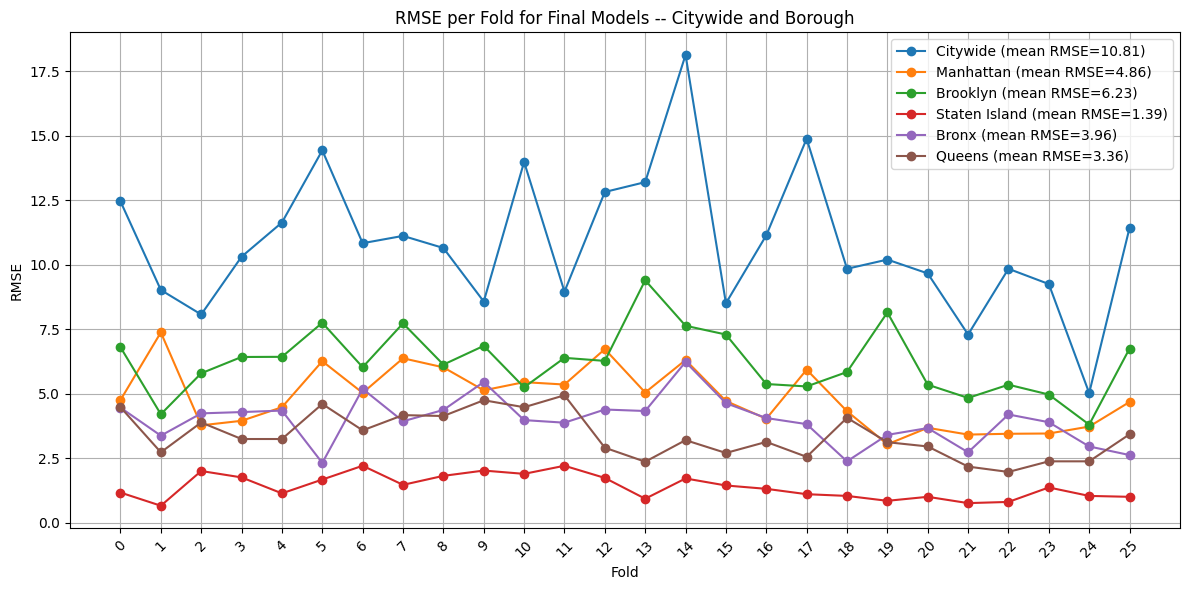

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

results = {"Citywide": citywide_results, "Manhattan": manhattan_results, "Brooklyn": brooklyn_results,
    "Staten Island": staten_island_results, "Bronx": bronx_results, "Queens": queens_results}

plt.figure(figsize=(12, 6))


# The shapes of the dataframe for citywide_results and {borough}_results differ so this code is clunkier than usual

for name, df in results.items():
    df_plot = df.copy()

    if 'rmse' in df_plot.columns:
        # Citywide: extract mean RMSE from 'mean' row
        if 'mean' in df_plot['fold'].values:
            mean_rmse = float(df_plot.loc[df_plot['fold'] == 'mean', 'rmse'])
            df_plot = df_plot[df_plot['fold'] != 'mean']  # drop mean row for plotting
        else:
            mean_rmse = df_plot['rmse'].mean()

        folds = df_plot['fold'].astype(str)
        rmse_values = df_plot['rmse']

    else:
        # Boroughs: mean row is an index
        if 'mean' in df_plot.index:
            mean_rmse = float(pd.to_numeric(df_plot.loc['mean'].values[0], errors='coerce'))
            df_plot = df_plot.loc[df_plot.index != 'mean']
        else:
            rmse_col = df_plot.columns[0]
            mean_rmse = pd.to_numeric(df_plot[rmse_col], errors='coerce').mean()

        # Convert RMSE to numeric, drop any NaNs
        rmse_col = df_plot.columns[0]
        df_plot[rmse_col] = pd.to_numeric(df_plot[rmse_col], errors='coerce')
        df_plot = df_plot.dropna()

        folds = df_plot.index.astype(str)
        rmse_values = df_plot[rmse_col]

    plt.plot(folds, rmse_values, marker='o', label=f"{name} (mean RMSE={mean_rmse:.2f})")

plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("RMSE per Fold for Final Models -- Citywide and Borough")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
import pandas as pd

rmse_data = {}

for name, df in results.items():
    df_plot = df.copy()

    if 'rmse' in df_plot.columns:
        df_plot = df_plot[df_plot['fold'] != 'mean']
        series = df_plot.set_index('fold')['rmse'].astype(float)
        series.index = series.index.astype(str)
    else:
        df_plot = df_plot.loc[df_plot.index != 'mean']
        rmse_col = df_plot.columns[0]
        series = pd.to_numeric(df_plot[rmse_col], errors='coerce').dropna()
        series.index = series.index.astype(str)

    rmse_data[name] = series

rmse_df = pd.DataFrame(rmse_data)
mean_row = rmse_df.mean(axis=0)
mean_row.name = 'mean'
rmse_df = pd.concat([rmse_df, mean_row.to_frame().T])
rmse_df = rmse_df.reset_index().rename(columns={'index': 'fold'})


rmse_df

,fold,Citywide,Manhattan,Brooklyn,Staten Island,Bronx,Queens
0,0,12.449900,4.750940,6.798109,1.164965,4.456135,4.472136
1,1,9.015859,7.372730,4.200340,0.654654,3.370036,2.725541
2,2,8.066686,3.770184,5.787918,2.000000,4.234214,3.882194
3,3,10.306032,3.946065,6.419835,1.752549,4.284524,3.240370
4,4,11.631239,4.472136,6.425396,1.133893,4.342481,3.240370
5,5,14.427157,6.256425,7.745967,1.669046,2.314550,4.598136
6,6,10.829853,5.028490,6.023762,2.203893,5.182388,3.575712
7,7,11.113055,6.369571,7.722879,1.463850,3.927922,4.166190
8,8,10.643576,6.017831,6.123724,1.812654,4.367085,4.131759
9,9,8.569047,5.126960,6.850443,2.017778,5.451081,4.743416
